Resumption of project for senior thesis

File created 1/25/2025

In [1]:
from g4beam import *
from scan import *

import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import numpy as np
import pandas as pd
from tqdm import *
import pickle
import itertools
from tabulate import tabulate
import scipy.optimize
import lzma
import os
import json
import time

# Varying beta

## Test 1

Small-scale test, to establish meaningful ranges

In [31]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 3)
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
betas

array([0.02, 0.03, 0.04])

In [32]:
# Meta-function (containing optimization)
def metafun(beta):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=2e-4))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_test1.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [19:52<00:00, 198.67s/it]


Saving to results/optimal_scans/beta_test1.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

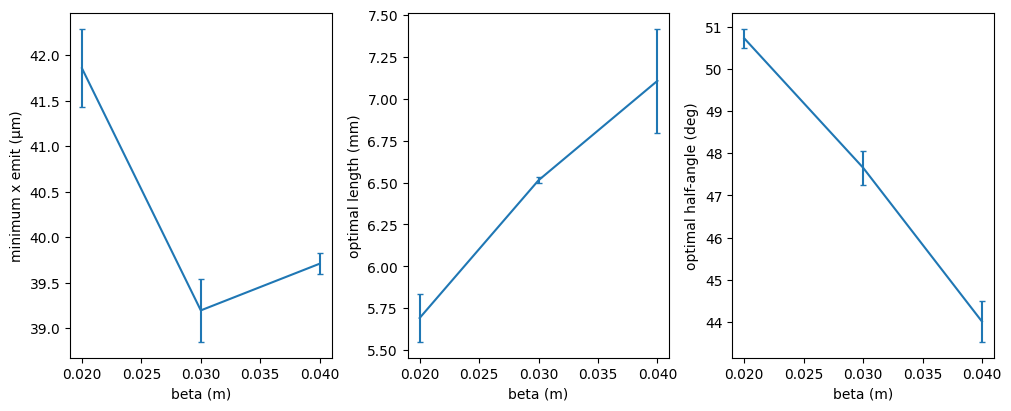

In [33]:
with open("results/optimal_scans/beta_test1.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

## Main test
Determined parameter ranges with some leeway: length 5-8 mm, half-angle 40-60 degrees, for a beta range of 0.02-0.04 m

In [74]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [52]:
# Meta-function (containing optimization)
def metafun(beta):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 47], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_a10.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [2:28:36<00:00, 198.14s/it]


Saving to results/optimal_scans/beta_a10.pkl
Results saved


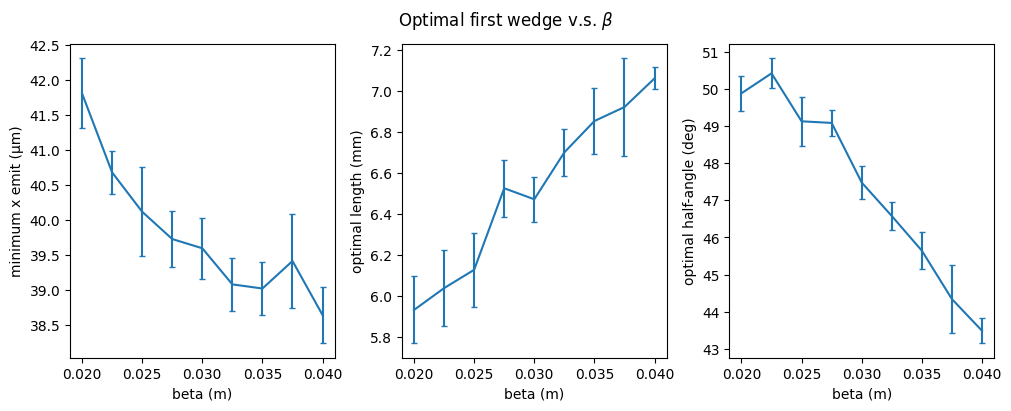

In [75]:
with open("results/optimal_scans/beta_a10.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

fig.suptitle(r"Optimal first wedge v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim.png")

# Varying alpha

## Test 1
Similar small-scale test, prepared for run

In [41]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(-0.5, 1, 4)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
alphas

array([-0.5,  0. ,  0.5,  1. ])

In [36]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=2e-4))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_test1.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [29:41<00:00, 222.67s/it]


Saving to results/optimal_scans/alpha_test1.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

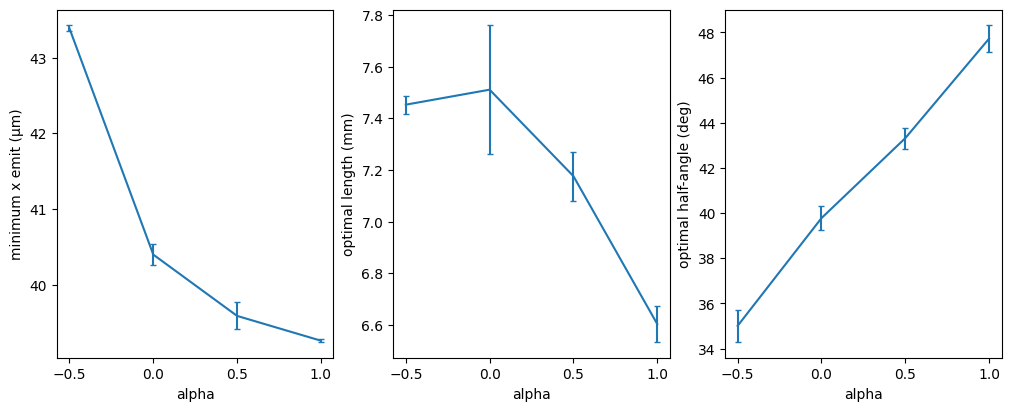

In [37]:
with open("results/optimal_scans/alpha_test1.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

## Test 2
Attempt to extend the range beyond 1.0, also testing changing the fatol to 1e-3

In [64]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(0.5, 1.5, 3)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 1, 8
a_min, a_max = 10, 70
alphas

array([0.5, 1. , 1.5])

In [47]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [7, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_test2.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [20:41<00:00, 206.92s/it]


Saving to results/optimal_scans/alpha_test2.pkl
Results saved


Text(0, 0.5, 'optimal half-angle (deg)')

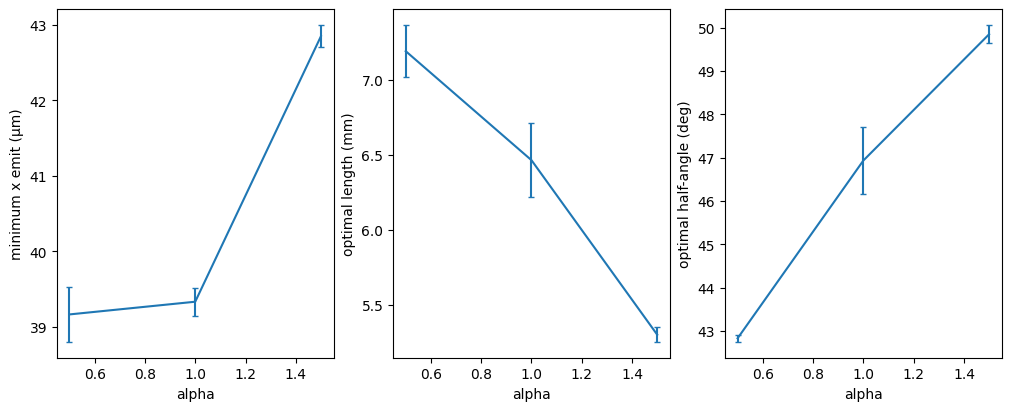

In [66]:
with open("results/optimal_scans/alpha_test2.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

## Main test

In [71]:
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# betas = np.linspace(0.02, 0.04, 3)
# alpha = 1     # dimensionless
alphas = np.linspace(0, 1.5, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 33, 53
alphas

array([0.    , 0.1875, 0.375 , 0.5625, 0.75  , 0.9375, 1.125 , 1.3125,
       1.5   ])

In [56]:
# Meta-function (containing optimization)
def metafun(alpha):
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    
    def func(x):
        length, angle = x
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 45], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max)), options=dict(fatol=1e-3))

result = run_scan(metafun, (alphas,), filename="results/optimal_scans/alpha_b30.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [2:31:04<00:00, 201.44s/it]


Saving to results/optimal_scans/alpha_b30.pkl
Results saved


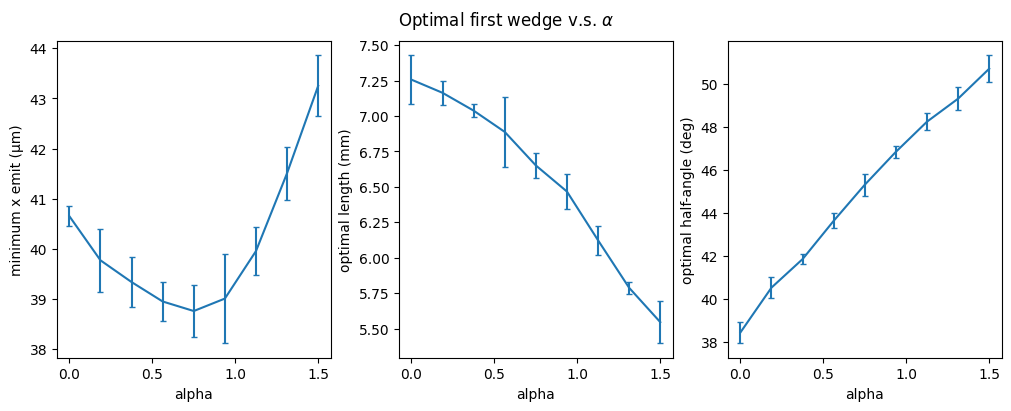

In [73]:
with open("results/optimal_scans/alpha_b30.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 4)
ax1.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"alpha")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"alpha")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(alphas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"alpha")
ax3.set_ylabel("optimal half-angle (deg)")

fig.suptitle(r"Optimal first wedge v.s. $\alpha$")

plt.savefig("./visuals/2025/alpha_optim.png")

# Optimization with alpha as a variable

## First run

In [78]:
# Initial experiment
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

res = list()
for _ in range(5):
    res.append(minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=5e-3)))

iter value
  42 3.81713e-02
iter value
  42 3.77335e-02
iter value
  37 3.77899e-02
iter value
  44 3.76143e-02
iter value
  36 3.80950e-02


In [81]:
print(pd.DataFrame({
    "Run": np.arange(1, 6),
    "x1": [r.x[0] for r in res],
    "x2": [r.x[1] for r in res],
    "x3": [r.x[2] for r in res],
    "Final Function Value": [r.fun for r in res]
}))

   Run        x1         x2        x3  Final Function Value
0    1  6.908695  42.845341  0.519546              0.038171
1    2  6.908832  43.715023  0.535097              0.037733
2    3  6.591758  43.901992  0.507193              0.037790
3    4  6.804697  42.504731  0.520910              0.037614
4    5  6.533230  45.570588  0.536185              0.038095


In [34]:
# Cell for quick experiments

t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 36    # mm

pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
# run_distribution(pre_w1, 7.5, 45, vd_dist, axis=0, debug=True)
%time res = run_distribution(pre_w1, 7.5, 45, vd_dist, axis=0)

CPU times: total: 156 ms
Wall time: 3.91 s


In [37]:
# Cell for quick experiments

t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=20000)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

# %time minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-3, fatol=5e-3))
%time minimize(func, [6.5, 47, 0.5], method="Powell", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xtol=1e-3))

iter value
   4 3.84687e-02
CPU times: total: 41.8 s
Wall time: 14min


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.03846865423722983
       x: [ 6.911e+00  4.567e+01  6.498e-01]
     nit: 4
   direc: [[ 1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00]
           [ 8.093e-04 -2.205e-01  1.263e-02]]
    nfev: 220

Demonstrated that the idea works. We can do the main run now

In [82]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [84]:
# Meta-function (containing optimization)
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [3:18:15<00:00, 264.35s/it]


Saving to results/optimal_scans/beta_var_alpha.pkl
Results saved


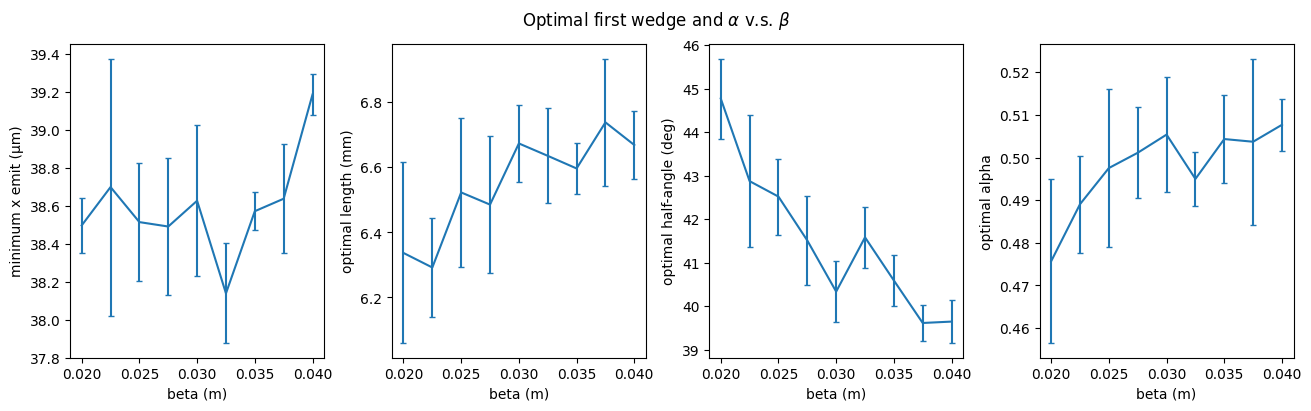

In [85]:
with open("results/optimal_scans/beta_var_alpha.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, layout="constrained")
fig.set_size_inches(13, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, results)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")

fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim_alpha.png")

A comparison: What happens if you lower `fatol`?

In [86]:
# Initial experiment
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

res = list()
for _ in range(5):
    res.append(minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(fatol=1e-4)))

iter value
  53 3.84761e-02
iter value
 225 3.80227e-02
iter value
 215 3.80754e-02
iter value
 234 3.76659e-02
iter value
 226 3.75708e-02


In [87]:
print(pd.DataFrame({
    "Run": np.arange(1, 6),
    "x1": [r.x[0] for r in res],
    "x2": [r.x[1] for r in res],
    "x3": [r.x[2] for r in res],
    "Final Function Value": [r.fun for r in res]
}))

   Run        x1         x2        x3  Final Function Value
0    1  6.834043  45.248040  0.509752              0.038476
1    2  6.725026  41.671399  0.511163              0.038023
2    3  7.024276  41.236328  0.522889              0.038075
3    4  6.557389  44.709938  0.514628              0.037666
4    5  6.825000  42.300000  0.525000              0.037571


Prohibitive instability, got it

## Second run
The big change is going up to 50K particles to hopefully curb error

In [82]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
al_min, al_max = 0.4, 0.6
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [84]:
# Meta-function (containing optimization)
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (al_min, al_max)), options=dict(fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 45/45 [3:18:15<00:00, 264.35s/it]


Saving to results/optimal_scans/beta_var_alpha.pkl
Results saved


In [ ]:
with open("results/optimal_scans/beta_var_alpha.pkl", "rb") as file:
    results = pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, layout="constrained")
fig.set_size_inches(13, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, results)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, results)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, results)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, results)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")

fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")

plt.savefig("./visuals/2025/beta_optim_alpha.png")

# Alpha variable optimization, another try

I don't know if this is any better

## Replicated initial experiment

Relatively quick checks of how long this is going to take

In [19]:
# Initial experiment
t_emit = 0.145
momentum = 100  # MeV/c
beta = 0.03    # m
# alpha = 1     # dimensionless
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 40, 55
    
def func(x):
    length, angle, alpha = x
    pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=24000)
    return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

res = list()
for _ in range(3):
    start = time.time()
    res.append(minimize(func, [6.5, 47, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-2, fatol=5e-3)))
    end = time.time()
    print(f"Took {(end-start)/60:.1f} minutes")
res

iter value
  22 3.84980e-02
Took 4.4 minutes
iter value
  24 3.83015e-02
Took 4.9 minutes
iter value
  24 3.83561e-02
Took 4.7 minutes


[       message: Optimization terminated successfully.
        success: True
         status: 0
            fun: 0.038498044385554216
              x: [ 7.079e+00  4.457e+01  5.295e-01]
            nit: 22
           nfev: 58
  final_simplex: (array([[ 7.079e+00,  4.457e+01,  5.295e-01],
                        [ 7.083e+00,  4.457e+01,  5.292e-01],
                        [ 7.080e+00,  4.457e+01,  5.294e-01],
                        [ 7.081e+00,  4.458e+01,  5.293e-01]]), array([ 3.850e-02,  3.910e-02,  3.913e-02,  3.929e-02])),
        message: Optimization terminated successfully.
        success: True
         status: 0
            fun: 0.03830145078021807
              x: [ 6.831e+00  4.360e+01  5.256e-01]
            nit: 24
           nfev: 66
  final_simplex: (array([[ 6.831e+00,  4.360e+01,  5.256e-01],
                        [ 6.831e+00,  4.361e+01,  5.256e-01],
                        [ 6.830e+00,  4.361e+01,  5.256e-01],
                        [ 6.831e+00,  4.361e+01,  5.2

**Notes**
- *12K particles, fatol=5e-3*: around 4-5 minutes to run, 30-40 iterations. Variation in final simplex looks considerable (~0.2e-2 or 5%)
- *12K particles, xatol=1e-3*: fails after max fev exceeded, variation in x seems less than 0.001 so I'm unsure what's going on. Maybe I should be setting a max fev
- *12K particles, maxfev=100*: now clamped to about 40 iterations, 4.4 min, simplex difference still none to 3 decimal places
- *12K particles, xatol=1*: This was essentially a test of whether xatol is working and it seems to not be
- At this point I realize that *both* `xatol` and `fatol` are taken into account, and when one is unset the other is set to default (which is atrociously low for fatol)
- *12K particles, xatol=1e-3, fatol=5e-3*: runs in around 3.3-3.7 minutes and 25-35 iterations, still 3 decimal points identical in x (less than 1e-3 variation, as expected) and slight variation of f(x) (~0.2e-2)
- *12K particles, xatol=1e-2, fatol=5e-3*: runs in 2.5-3.1 minutes, 19-25 iterations, still almost no difference in x although last decimal place differences are now seen. I'm not sure if it's doing absolute or relative, as I see about the same relative difference in all 3 x-coordinates despite them being an order of magitude apart
- *24K particles, xatol=1e-2, fatol=5e-3*: runs in 4.4-4.7 minutes, 22-24 iterations, same differences in x coordinate, differences in function value reduced below 0.1e-02. Seems that there's a linear tradeoff between particle count and time and increasing particle count helps control function variation

## Small-scale test

In [15]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 3)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02, 0.03, 0.04])

In [16]:
# Meta-function (containing optimization)
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-2, fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha_test.pkl", trials=2)

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [16:10<00:00, 161.73s/it]


Saving to results/optimal_scans/beta_var_alpha_test.pkl
Results saved


Text(0.5, 0.98, 'Optimal first wedge and $\\alpha$ v.s. $\\beta$')

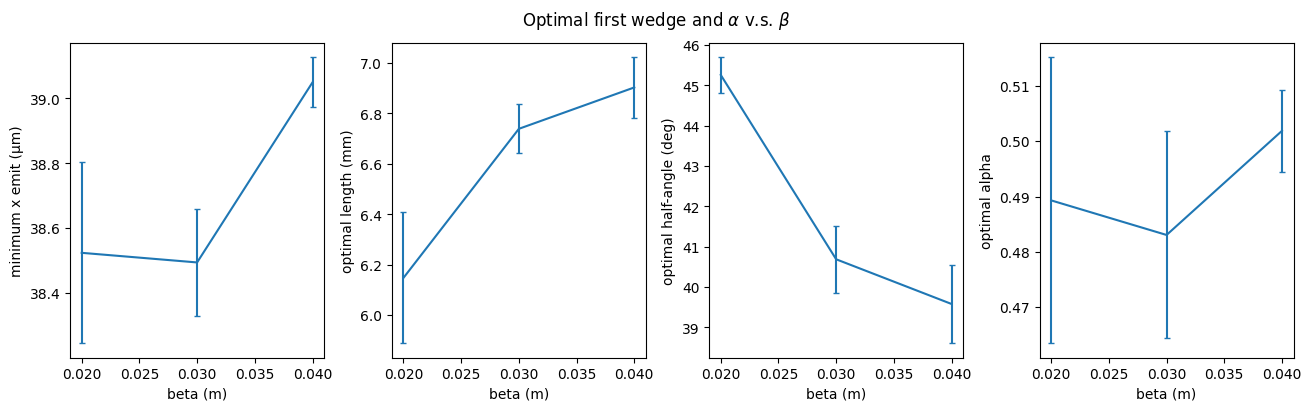

In [18]:
def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, layout="constrained")
fig.set_size_inches(13, 4)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, result)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, result)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, result)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, result)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")

fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")

## Main run

I'm going to bed.

In [3]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.04, 9)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
       0.04  ])

In [39]:
# Trying to compose two different linspaces
# np.linspace(0.02, 0.04, 9), np.linspace(0.02125, 0.03875, 8), np.linspace(0.02, 0.04, 17)
betas = np.linspace(0.02125, 0.03875, 8)
betas

(array([0.02  , 0.0225, 0.025 , 0.0275, 0.03  , 0.0325, 0.035 , 0.0375,
        0.04  ]),
 array([0.02125, 0.02375, 0.02625, 0.02875, 0.03125, 0.03375, 0.03625,
        0.03875]),
 array([0.02   , 0.02125, 0.0225 , 0.02375, 0.025  , 0.02625, 0.0275 ,
        0.02875, 0.03   , 0.03125, 0.0325 , 0.03375, 0.035  , 0.03625,
        0.0375 , 0.03875, 0.04   ]))

In [32]:
# Run it again to add more results
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=24000)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-2, fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha_2_b.pkl", trials=10)

100%|███████████████████████████████████████████████████████████████████████████████| 18/18 [1:19:53<00:00, 266.33s/it]


Saving to results/optimal_scans/beta_var_alpha_2_a.pkl
Results saved


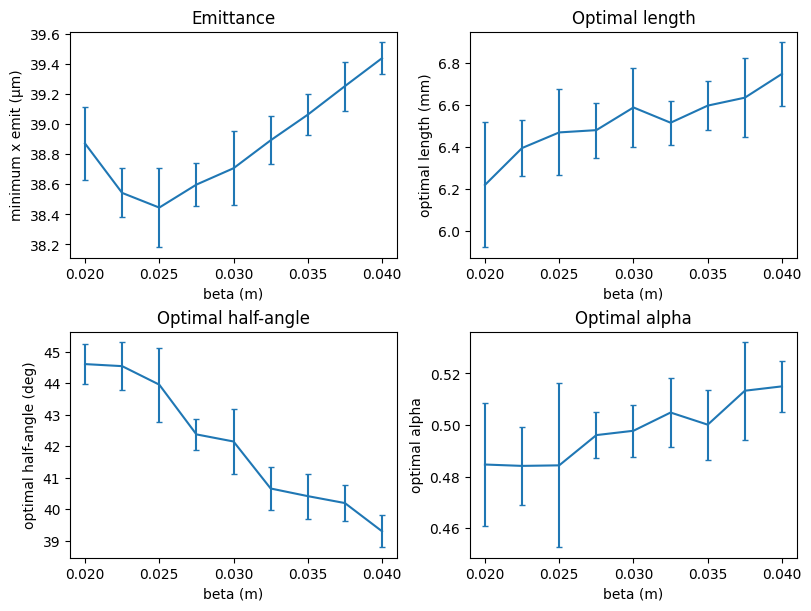

In [4]:
results_paths = [
    "results/optimal_scans/beta_var_alpha_2.pkl",
    "results/optimal_scans/beta_var_alpha_2_a.pkl"
]
result = []
for f in results_paths:
    with open(f, "rb") as file:
        result += pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, layout="constrained")
fig.set_size_inches(8, 6)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, result)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")
ax1.set_title("Emittance")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, result)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")
ax2.set_title("Optimal length")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, result)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")
ax3.set_title("Optimal half-angle")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, result)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")
ax4.set_title("Optimal alpha")

# fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")
plt.savefig("visuals/2025/optim_new.png")

## Zoom in

Add more data points around the optimal region to get a better idea of the curve

In [44]:
t_emit = 0.145
momentum = 100  # MeV/c
# betas = np.linspace(0.02, 0.03, 9)
betas = np.linspace(0.02125, 0.02875, 4)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02125, 0.02375, 0.02625, 0.02875])

In [ ]:
# Run it again to add more results
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=24000)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-2, fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha_2_b.pkl", trials=10)

 18%|██████████████                                                                  | 7/40 [39:53<3:05:39, 337.55s/it]

## Yet another run

Zooming in on the optimal region, adding more particles, more data points, doing fewer trials to save time

In [2]:
t_emit = 0.145
momentum = 100  # MeV/c
# beta = 0.03    # m
betas = np.linspace(0.02, 0.03, 11)
l_emit = 1      # mm
pz_std = 0.8
vd_dist = 24    # mm

d_min, d_max = 5, 8
a_min, a_max = 20, 60
betas

array([0.02 , 0.021, 0.022, 0.023, 0.024, 0.025, 0.026, 0.027, 0.028,
       0.029, 0.03 ])

In [3]:
def metafun(beta):
    
    def func(x):
        length, angle, alpha = x
        pre_w1 = gen_distribution((beta, alpha, t_emit, 0, 0), (beta, alpha, t_emit, 0, 0), momentum, pz_std, z_emit=l_emit, N=50000)
        return emittances(cut_outliers(run_distribution(pre_w1, length, angle, vd_dist, axis=0)))[0]

    return scipy.optimize.minimize(func, [6.5, 40, 0.5], method="Nelder-Mead", bounds=((d_min, d_max), (a_min, a_max), (0, 1)), options=dict(xatol=1e-2, fatol=5e-3))

result = run_scan(metafun, (betas,), filename="results/optimal_scans/beta_var_alpha_3.pkl", trials=5)

100%|███████████████████████████████████████████████████████████████████████████████| 55/55 [7:44:57<00:00, 507.23s/it]


Saving to results/optimal_scans/beta_var_alpha_3.pkl
Results saved


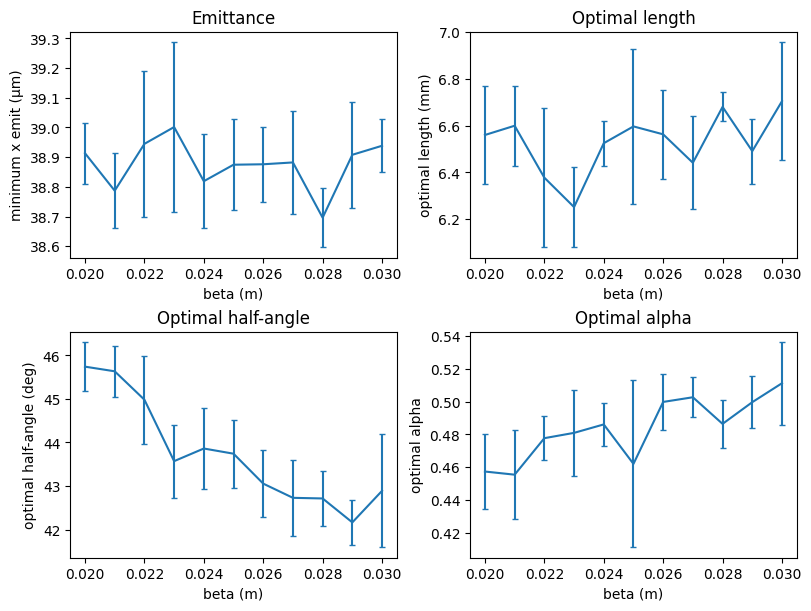

In [4]:
results_paths = [
    "results/optimal_scans/beta_var_alpha_3.pkl"
]
result = []
for f in results_paths:
    with open(f, "rb") as file:
        result += pickle.load(file)

def optim_fun(optim_result):
    return optim_result.fun*1000 # mm --> μm

def optim_x1(optim_result):
    return optim_result.x[0]

def optim_x2(optim_result):
    return optim_result.x[1]

def optim_x3(optim_result):
    return optim_result.x[2]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, layout="constrained")
fig.set_size_inches(8, 6)
ax1.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_fun, result)), capsize=2)
ax1.set_xlabel(r"beta (m)")
ax1.set_ylabel("minimum x emit (μm)")
ax1.set_title("Emittance")

ax2.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x1, result)), capsize=2)
ax2.set_xlabel(r"beta (m)")
ax2.set_ylabel("optimal length (mm)")
ax2.set_title("Optimal length")

ax3.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x2, result)), capsize=2)
ax3.set_xlabel(r"beta (m)")
ax3.set_ylabel("optimal half-angle (deg)")
ax3.set_title("Optimal half-angle")

ax4.errorbar(*qmap_to_arrays(betas, calc_quantity(optim_x3, result)), capsize=2)
ax4.set_xlabel(r"beta (m)")
ax4.set_ylabel("optimal alpha")
ax4.set_title("Optimal alpha")

# fig.suptitle(r"Optimal first wedge and $\alpha$ v.s. $\beta$")
plt.savefig("visuals/2025/optim_new_2.png")

In [29]:
# This code partially produced by ChatGPT
def optim_result_to_df(data, indep_var_names, obj_func_name, opt_var_names):
    """
    Convert a list of optimization results into a pandas DataFrame.
    
    Parameters:
    data : list
        List of tuples with format (indep_var_1, indep_var_2, ..., optim_result), where optim_result
        has attributes `fun` and `x` (a list-like with variable length).
    indep_var_names : list of str
        List of names for the independent variable columns.
    obj_func_name : str
        Name of the optimized function result column.
    opt_var_names : list of str
        List of names for the optimized variables (must match the length of optim_result.x).
    
    Returns:
    pd.DataFrame
        DataFrame containing the structured data.
    
    Raises:
    ValueError
        If `optim_result.x` is empty.
    """
    extracted_data = []
    
    for row in data:
        optim_result = row[-1]
        if len(optim_result.x) == 0:
            raise ValueError("Optimized variables (optim_result.x) are empty.")
        extracted_data.append(list(row[:-1]) + [optim_result.fun] + list(optim_result.x))
    
    column_names = indep_var_names + [obj_func_name] + opt_var_names
    
    return pd.DataFrame(extracted_data, columns=column_names)

def plot_with_errorbars(ax, grouped, column, xlabel, ylabel, title):
    betas = grouped.index.values
    mean, std = grouped[column].values.T
    ax.errorbar(betas, mean, yerr=std, capsize=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

In [32]:
results_paths = [
    "results/optimal_scans/beta_var_alpha_2.pkl",
    "results/optimal_scans/beta_var_alpha_2_a.pkl"
]
result = []
for f in results_paths:
    with open(f, "rb") as file:
        result += pickle.load(file)
df = optim_result_to_df(result, ["beta"], "emit", ["length", "half_angle", "alpha"])

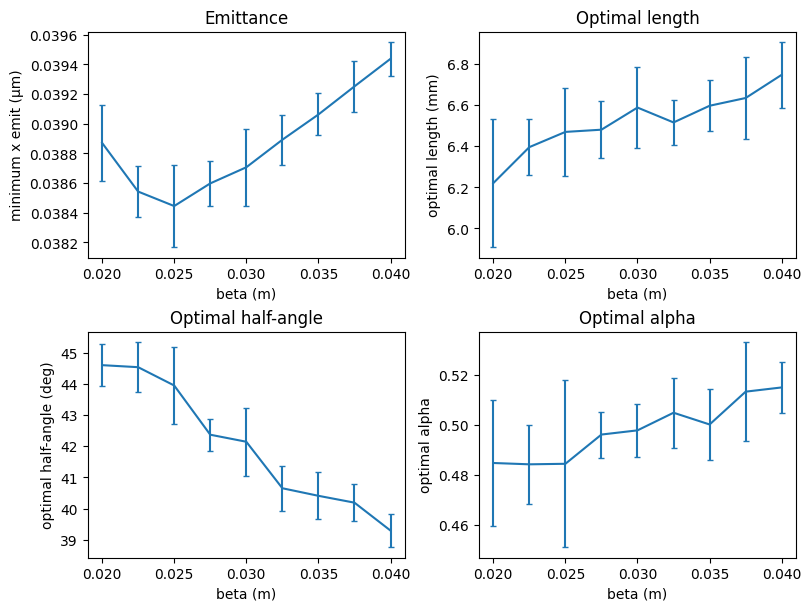

In [33]:
# This code produced by ChatGPT
grouped = df.groupby("beta").agg(["mean", "std"])

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, layout="constrained")
fig.set_size_inches(8, 6)

plot_with_errorbars(ax1, grouped, "emit", r"beta (m)", "minimum x emit (μm)", "Emittance")
plot_with_errorbars(ax2, grouped, "length", r"beta (m)", "optimal length (mm)", "Optimal length")
plot_with_errorbars(ax3, grouped, "half_angle", r"beta (m)", "optimal half-angle (deg)", "Optimal half-angle")
plot_with_errorbars(ax4, grouped, "alpha", r"beta (m)", "optimal alpha", "Optimal alpha")

plt.show()